<a href="https://colab.research.google.com/github/aryasuram/scratchpad/blob/main/Assignment_01_Wrangling_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [454]:
! git clone https://github.com/aryasuram/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

In [455]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

Question 1.1

In [456]:
# Import and look at data. We can see when sorted by Price in descending order, the highest value is only 999
df_airbnb = pd.read_csv('./data/airbnb_NYC.csv', encoding = 'latin1')
df_airbnb.sort_values(by='Price', ascending = False)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
17430,10963050,1/2/2014,3BR Luxury Apartment in SoHo,Manhattan,Apartment,NaN,Entire home/apt,10012.0,3.0,1,0,999,NaN
17664,11260309,1/13/2014,Huge Union Square Loft,Manhattan,Apartment,NaN,Entire home/apt,10003.0,2.0,1,0,999,NaN
26751,30247261,3/30/2015,NEW 2850 SQ FT SOHO/LittleItaly GEM,Manhattan,Apartment,NaN,Entire home/apt,10013.0,4.0,1,0,999,NaN
2955,687750,6/10/2011,Super Big Sunny room. Great view!!!,Manhattan,Apartment,85.0,Private room,10044.0,2.0,1,9,999,88.0
14884,8107868,8/12/2013,Huge Remodeled Home in Prime Area,Manhattan,Apartment,NaN,Entire home/apt,10014.0,3.0,1,0,999,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,1420300,11/18/2011,8 Bedrooms 5 Baths 20 mnts to SOHO,Brooklyn,House,90.0,Entire home/apt,11216.0,16.0,1,36,"1,000",92.0
17783,11459436,1/19/2014,SUPERBOWL RENTAL,Manhattan,Apartment,NaN,Entire home/apt,10002.0,1.0,1,0,"1,000",NaN
8702,3323488,8/20/2012,Photoshoot/Video- Historic Townhome,Brooklyn,House,NaN,Entire home/apt,11216.0,3.0,1,0,"1,000",NaN
25144,25067295,12/21/2014,East Village / Gramercy Park 2 BR,Manhattan,Apartment,NaN,Entire home/apt,10003.0,2.0,1,0,"1,000",NaN


In [457]:
df_airbnb.dtypes # see what 'Price' is casted in currently

,0
Host Id,int64
Host Since,object
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [458]:
df_airbnb['Price'].unique()
# The issue here is that some values contain commas which doesn't allow it to be casted as an int
# This is why the maximum value in the tabel above is only 999, even though there are larger prices
# This also means that 'Price' is casted as a string

array(['145', '37', '28', '199', '549', '149', '250', '90', '270', '290',
       '170', '59', '49', '68', '285', '75', '100', '150', '700', '125',
       '175', '40', '89', '95', '99', '499', '120', '79', '110', '180',
       '143', '230', '350', '135', '85', '60', '70', '55', '44', '200',
       '165', '115', '74', '84', '129', '50', '185', '80', '190', '140',
       '45', '65', '225', '600', '109', '1,990', '73', '240', '72', '105',
       '155', '160', '42', '132', '117', '295', '280', '159', '107', '69',
       '239', '220', '399', '130', '375', '585', '275', '139', '260',
       '35', '133', '300', '289', '179', '98', '195', '29', '27', '39',
       '249', '192', '142', '169', '1,000', '131', '138', '113', '122',
       '329', '101', '475', '238', '272', '308', '126', '235', '315',
       '248', '128', '56', '207', '450', '215', '210', '385', '445',
       '136', '247', '118', '77', '76', '92', '198', '205', '299', '222',
       '245', '104', '153', '349', '114', '320', '292', '22

In [459]:
# Remove commas from prices and replace with nothing
df_airbnb['Price'] = (df_airbnb['Price'].str.replace(",", ""))
# convert all prices from strings to int values
df_airbnb['Price'] = pd.to_numeric(df_airbnb['Price'],errors='coerce')

In [460]:
df_airbnb['Price'].unique()

array([  145,    37,    28,   199,   549,   149,   250,    90,   270,
         290,   170,    59,    49,    68,   285,    75,   100,   150,
         700,   125,   175,    40,    89,    95,    99,   499,   120,
          79,   110,   180,   143,   230,   350,   135,    85,    60,
          70,    55,    44,   200,   165,   115,    74,    84,   129,
          50,   185,    80,   190,   140,    45,    65,   225,   600,
         109,  1990,    73,   240,    72,   105,   155,   160,    42,
         132,   117,   295,   280,   159,   107,    69,   239,   220,
         399,   130,   375,   585,   275,   139,   260,    35,   133,
         300,   289,   179,    98,   195,    29,    27,    39,   249,
         192,   142,   169,  1000,   131,   138,   113,   122,   329,
         101,   475,   238,   272,   308,   126,   235,   315,   248,
         128,    56,   207,   450,   215,   210,   385,   445,   136,
         247,   118,    77,    76,    92,   198,   205,   299,   222,
         245,   104,

In [461]:
# When sorted by Price in descending order, we can see the large values are actually at the top now that there are no commas
df_airbnb.sort_values(by='Price', ascending = False)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating
23927,23248648,11/2/2014,NO LONGER BOOKING RESERVATIONS,Manhattan,Apartment,95.0,Entire home/apt,10025.0,2.0,1,21,10000,95.0
4002,1177497,9/18/2011,Film Location,Brooklyn,House,NaN,Entire home/apt,11205.0,5.0,1,0,8000,NaN
17900,11598359,1/24/2014,SUPER BOWL Brooklyn Duplex Apt!!,Brooklyn,Apartment,NaN,Entire home/apt,11238.0,4.0,1,0,6500,NaN
2405,496780,4/9/2011,test listing which is not real,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,5.0,1,0,5999,NaN
7550,2675644,6/18/2012,Turn of the Century Film Location,Staten Island,House,40.0,Entire home/apt,10301.0,12.0,1,1,5000,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25139,25038105,12/20/2014,Cool Harlem Room available / shared,Manhattan,House,NaN,Shared room,10027.0,1.0,1,0,20,NaN
18209,12122005,2/10/2014,Private Room in Bushwick Warehouse,Brooklyn,Apartment,NaN,Private room,11237.0,1.0,1,0,20,NaN
3120,751530,6/27/2011,Room in three-Bedroom Apartment,Brooklyn,Apartment,NaN,Entire home/apt,NaN,1.0,1,0,10,NaN
30087,41211757,8/11/2015,"Private Room in Brooklyn, NY",Brooklyn,Apartment,NaN,Private room,11219.0,1.0,1,0,10,NaN


In [462]:
# We can also confirm that the 'Price' variable has been changed to an int
df_airbnb.dtypes

,0
Host Id,int64
Host Since,object
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [463]:
# This shows that the price variable has no missing values
np.sum(df_airbnb.isna(), axis=0)

,0
Host Id,0
Host Since,3
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8323
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


Question 1.2

In [464]:
df_police = pd.read_csv('./data/mn_police_use_of_force.csv')
df_police.head(75)

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2016/01/07 21:22:30,Damage Property-In Progress,Yes,BURGTL,NaN,Bodily Force,Body Weight to Pin,Black,Male,23.0,Fled on Foot,3,East Phillips
71,2016/01/07 21:22:30,Damage Property-In Progress,Yes,BURGTL,NaN,Gun Point Display,Compliance,Black,Male,23.0,Fled on Foot,3,East Phillips
72,2016/01/08 09:26:08,Emotionally Disturb Person,Yes,ASLT4,Yes,Bodily Force,Punches,Native American,Male,28.0,Assaulted Officer,4,Folwell
73,2016/01/08 09:26:08,Emotionally Disturb Person,Yes,ASLT4,Yes,Taser,Touch,Native American,Male,28.0,Assaulted Officer,4,Folwell


In [465]:
df_police['subject_injury'].unique()

array([nan, 'No', 'Yes'], dtype=object)

In [466]:
np.sum(df_police.isna(), axis=0)

,0
response_datetime,0
problem,0
is_911_call,0
primary_offense,0
subject_injury,9848
force_type,0
force_type_action,0
race,1024
sex,501
age,1066


In [467]:
df_police.shape

(12925, 13)

In [468]:
proportion_missing = 9848/12925
print("The proportion of values that are missing is: ", proportion_missing)

The proportion of values that are missing is:  0.7619342359767892


In [469]:
df_police['force_type'].unique()

array(['Bodily Force', 'Chemical Irritant', 'Taser', 'Improvised Weapon',
       'Gun Point Display', 'Police K9 Bite', 'Baton', 'Firearm',
       'Less Lethal Projectile', 'Maximal Restraint Technique',
       'Less Lethal'], dtype=object)

In [470]:
pd.crosstab(df_police['subject_injury'], df_police['force_type'], dropna=False)

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


In [471]:
# I am going to replace all missing values of subject injury with 'Yes' because feasibly, any one of
# the force types listed can cause boidly harm, so it is better to classify all cases as injurious
# just in case an injury actually did happen. It is better to be safe and say an injury did occur
# rather than be risky and state that an injury did not occur when in actuality, it did.
df_police['subject_injury_cleaned'] = df_police['subject_injury'].fillna('Yes')
df_police.head(75)

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood,subject_injury_cleaned
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East,Yes
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West,Yes
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West,Yes
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West,Yes
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2016/01/07 21:22:30,Damage Property-In Progress,Yes,BURGTL,NaN,Bodily Force,Body Weight to Pin,Black,Male,23.0,Fled on Foot,3,East Phillips,Yes
71,2016/01/07 21:22:30,Damage Property-In Progress,Yes,BURGTL,NaN,Gun Point Display,Compliance,Black,Male,23.0,Fled on Foot,3,East Phillips,Yes
72,2016/01/08 09:26:08,Emotionally Disturb Person,Yes,ASLT4,Yes,Bodily Force,Punches,Native American,Male,28.0,Assaulted Officer,4,Folwell,Yes
73,2016/01/08 09:26:08,Emotionally Disturb Person,Yes,ASLT4,Yes,Taser,Touch,Native American,Male,28.0,Assaulted Officer,4,Folwell,Yes


In [472]:
# subject injury cleaned has no missing values
np.sum(df_police.isna(), axis=0)

,0
response_datetime,0
problem,0
is_911_call,0
primary_offense,0
subject_injury,9848
force_type,0
force_type_action,0
race,1024
sex,501
age,1066


In [473]:
pd.crosstab(df_police['subject_injury_cleaned'], df_police['force_type'], dropna=False)

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury_cleaned,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,4,8337,1462,0,71,114,87,2,170,75,1157


In the previous cross tabulation between the actual subject injury column and force type, it seemed that there was a fairly equal distribution of force types that both caused and did not cause injuries. The only force types that had varying values were 'chemical irritant' which had fewer injuries, and 'Police K9 Bite,' which had more injuries. When using the cleaned subject injury values, which replaced all missing values with 'Yes' to injury to serve as a precaution, the number of subject injuries is artifically inflated across all force types. It seemed that most of the missing values were for bodily force (which is somewhat hard to classify as injurious or not), followed by chemical irritants and tasers.

Question 1.3

In [474]:
df_meta = pd.read_csv('./data/metabric.csv')
df_meta.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


In [475]:
df_meta['Overall Survival Status'].unique()

array(['0:LIVING', '1:DECEASED'], dtype=object)

In [476]:
df_meta['Overall Survival Status'] = df_meta['Overall Survival Status'].str.replace('0:LIVING', '1')
df_meta['Overall Survival Status'] = df_meta['Overall Survival Status'].str.replace('1:DECEASED', '0')
df_meta['Overall Survival Status'] = pd.to_numeric(df_meta['Overall Survival Status'],errors='coerce')

df_meta.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,1,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,0,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,1,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,0,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,0,YES,5.230071,31.0,4.0


In [477]:
df_meta.dtypes

,0
Age at Diagnosis,float64
Type of Breast Surgery,object
Cancer Type,object
Chemotherapy,object
Hormone Therapy,object
Lymph nodes examined positive,float64
Mutation Count,float64
Nottingham prognostic index,float64
Overall Survival (Months),float64
Overall Survival Status,int64


Question 1.4

In [478]:
np.sum(df_airbnb.isna(), axis=0)

,0
Host Id,0
Host Since,3
Name,0
Neighbourhood,0
Property Type,3
Review Scores Rating (bin),8323
Room Type,0
Zipcode,134
Beds,85
Number of Records,0


There are 8323 missing values for 'Review Scores Rating'

In [479]:
imputation_value = df_airbnb['Review Scores Rating'].median()
df_airbnb['Review Scores Rating Imp'] = df_airbnb['Review Scores Rating'].fillna(imputation_value)
df_airbnb.head(15)

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Review Scores Rating Imp
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN,94.0
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN,94.0
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN,94.0
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,94.0
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,96.0
5,1039,7/25/2008,Big Greenpoint 1BD w/ Skyline View,Brooklyn,Apartment,100.0,Entire home/apt,11222.0,1.0,1,4,149,100.0,100.0
6,1783,8/12/2008,Amazing Also,Manhattan,Apartment,100.0,Entire home/apt,10004.0,1.0,1,9,250,100.0,100.0
7,2078,8/15/2008,"Colorful, quiet, & near the subway!",Brooklyn,Apartment,90.0,Private room,11201.0,1.0,1,80,90,94.0,94.0
8,2339,8/20/2008,East Village Cocoon: 2 Bedroom Flat,Manhattan,Apartment,90.0,Entire home/apt,10009.0,2.0,1,95,270,90.0,90.0
9,2339,8/20/2008,Lovely 2 Bedroom East Village Nest,Manhattan,Apartment,95.0,Entire home/apt,10009.0,2.0,1,23,290,96.0,96.0


Replacing the NaN values with the median value might negatively impact my results because it will artifically concentrate the values closer to the median.

# Question 2

Question 2.1

In [480]:
df_shark_attacks = pd.read_excel('./GSAF5.xls')
df_shark_attacks.head()


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,...,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,...,Unknown,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,...,1.7m Seven Gill shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,...,Bull shark,Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,...,Bull shark,Andy Currie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Question 2.2

In [481]:
drop_cols = ['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1', 'original order', 'Unnamed: 21', 'Unnamed: 22']
df_shark_attacks = df_shark_attacks.drop(columns = drop_cols)
df_shark_attacks.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source
0,29th January,2026.0,Unprovoked,Brazil,Recife,Del Chifre Beach in Olinda,Swimming,Deivson Rocha Dantas,M,13,Right thigh and lower leg stripped of flesh,Y,?,Unknown bull and tiger sharks frequent the area,Kevin McMurray Trackingsharks.com: TV Globo: P...
1,29th January,2026.0,Unprovoked,Australia,NSW,Angels Beach East Ballina,Surfing,Unnamed man,M,?,No injury shark knocked man of his board,N,1100hrs,Unknown,Bob Myatt GSAF
2,24th January,2026.0,Unprovoked,Australia,Tasmania,Cooee Beach west of Burnie,Swimming,Megan Stokes,F,?,Puncture wounds to right knee,N,1815hrs,1.7m Seven Gill shark,Bob Myatt GSAF
3,20th January,2026.0,Unprovoked,Australia,NSW,Point Plomber North of Port Macquarie,Surfing,Paul Zvirdinas,M,39,Minor cuts and abrasions,N,0830hrs,Bull shark,Bob Myatt GSAF
4,19th January,2026.0,Unprovoked,Australia,NSW,Dee Why,Surfing,Unknown,M,11,None reported damage to board,N,1145hrs,Bull shark,Andy Currie


In [482]:
df_shark_attacks.shape

(7074, 15)

Question 2.3

For me, each observation is a a recorded shark attack on a human. This can be justified as each row has a location of the incident, descriptors about the person attacked, the time of the attacking, and other key information regarding the shark attacks. This will affect my choices in cleaning variables in a few ways. For example, for the variable 'year,' some values are 0.0 because the event was recorded ambiguously, or rather, without a specific date; so, if I want to, I could look through these 0.0 values and assign rough estimates of the dates of the attacks. Additionally, some observations are of watercrafts and not people, meaning their inclusion in the human-affected shark attacks may not occur as they are not humans.

Question 2.4

In [483]:
df_shark_attacks['Year'].unique()

array([2026., 2016., 2025., 2024., 2023., 2022., 2021., 2020., 2019.,
       2018., 2017.,   nan, 2015., 2014., 2013., 2012., 2011., 2010.,
       2009., 2008., 2007., 2006., 2005., 2004., 2003., 2002., 2001.,
       2000., 1999., 1998., 1997., 1996., 1995., 1984., 1994., 1993.,
       1992., 1991., 1990., 1989., 1969., 1988., 1987., 1986., 1985.,
       1983., 1982., 1981., 1980., 1979., 1978., 1977., 1976., 1975.,
       1974., 1973., 1972., 1971., 1970., 1968., 1967., 1966., 1965.,
       1964., 1963., 1962., 1961., 1960., 1959., 1958., 1957., 1956.,
       1955., 1954., 1953., 1952., 1951., 1950., 1949., 1948., 1848.,
       1947., 1946., 1945., 1944., 1943., 1942., 1941., 1940., 1939.,
       1938., 1937., 1936., 1935., 1934., 1933., 1932., 1931., 1930.,
       1929., 1928., 1927., 1926., 1925., 1924., 1923., 1922., 1921.,
       1920., 1919., 1918., 1917., 1916., 1915., 1914., 1913., 1912.,
       1911., 1910., 1909., 1908., 1907., 1906., 1905., 1904., 1903.,
       1902., 1901.,

In [484]:
df_shark_attacks = df_shark_attacks[df_shark_attacks['Year'] >= 1940]
df_shark_attacks.shape

(5538, 15)

In [485]:
df_shark_attacks['Year'].unique()

array([2026., 2016., 2025., 2024., 2023., 2022., 2021., 2020., 2019.,
       2018., 2017., 2015., 2014., 2013., 2012., 2011., 2010., 2009.,
       2008., 2007., 2006., 2005., 2004., 2003., 2002., 2001., 2000.,
       1999., 1998., 1997., 1996., 1995., 1984., 1994., 1993., 1992.,
       1991., 1990., 1989., 1969., 1988., 1987., 1986., 1985., 1983.,
       1982., 1981., 1980., 1979., 1978., 1977., 1976., 1975., 1974.,
       1973., 1972., 1971., 1970., 1968., 1967., 1966., 1965., 1964.,
       1963., 1962., 1961., 1960., 1959., 1958., 1957., 1956., 1955.,
       1954., 1953., 1952., 1951., 1950., 1949., 1948., 1947., 1946.,
       1945., 1944., 1943., 1942., 1941., 1940.])

<Axes: ylabel='Frequency'>

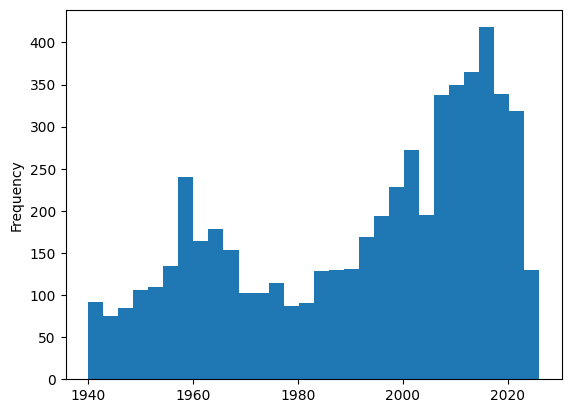

In [486]:
df_shark_attacks['Year'].plot.hist(bins=30)

Based on the histogram above, it would seem that shark attacks have been increasing since the 1940s, with the frequency of shark attacks recently tripling the numbers from the 1940s. Of late, the frequency of shark attacks seems to be decreasing slightly and might stabilize around at around 300 attacks per year.

Question 2.5

In [487]:
df_shark_attacks['Age'].unique()

array(['13', '?', '39', '11', '27', '12', '26', '56', '55', '24', '25',
       '61', '40', '14', '50+', '54', '48', '57', '8', '63', '9', '19',
       '7', '85', '69', '18', '66', '21', '37', '16', '20', '42', '45',
       '30', '30+', '40+', '29', 35, 58, 29, 24, 20, 55, 17, 12, 37, 36,
       23, 40, 28, 69, 48, '60+', 57, 45, 61, 27, 38, 16, 68, 33, 30, 15,
       41, 14, 43, 26, 'Middle age', 18, 21, 49, 25, 46, 19, 65, 64, nan,
       '46', '32', '10', '64', '62', '22', '15', '52', '44', '47', '59',
       '50', '34', '38', '30s', '20/30', '35', '65', '20s', '77', '60',
       '49', '!2', '73', '50s', '58', '67', '17', '6', '41', '53', '68',
       '43', '51', '31', 39, 51, 10, 13, 60, '40s', 62, 'teen', 8, 22, 32,
       56, 'Teen', 42, 50, 'M', 9, 31, 11, 34, '!6', '!!', 47, 7, 71, 59,
       53, 54, 75, '45 and 15', 73, 52, 70, 4, 63, 44, '28 & 22',
       '22, 57, 31', '60s', "20's", 67, 74, '9 & 60', 'a minor', 6, 3, 82,
       '40?', 66, 72, '23', '36', '71', '70', '18 month

In [488]:
df_shark_attacks['Age'] = pd.to_numeric(df_shark_attacks['Age'],errors='coerce')
df_shark_attacks['Age'].unique()

array([13., nan, 39., 11., 27., 12., 26., 56., 55., 24., 25., 61., 40.,
       14., 54., 48., 57.,  8., 63.,  9., 19.,  7., 85., 69., 18., 66.,
       21., 37., 16., 20., 42., 45., 30., 29., 35., 58., 17., 36., 23.,
       28., 38., 68., 33., 15., 41., 43., 49., 46., 65., 64., 32., 10.,
       62., 22., 52., 44., 47., 59., 50., 34., 77., 60., 73., 67.,  6.,
       53., 51., 31., 71., 75., 70.,  4., 74.,  3., 82., 72.,  5., 86.,
       84., 87.,  1., 81., 78.])

<Axes: ylabel='Frequency'>

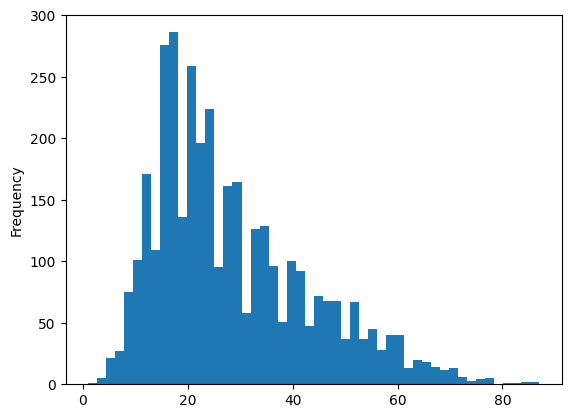

In [489]:
df_shark_attacks['Age'].plot.hist(bins = 50)

It seems that mostly teenagers and young adults are afflicted by shark attacks, which makes sense considering people at this age are more likely to partake in riskier behavior.

Question 2.6

In [490]:
df_shark_attacks['Type'].unique()

array(['Unprovoked', 'Provoked', 'Questionable', 'unprovoked',
       ' Provoked', 'Watercraft', 'Sea Disaster', nan, '?', 'Unconfirmed',
       'Unverified', 'Invalid', 'Under investigation', 'Boat'],
      dtype=object)

In [491]:
df_shark_attacks['Type'] = (df_shark_attacks['Type'].str.replace('unprovoked', 'Unprovoked')
                                                    .str.replace(' Provoked', 'Provoked')
                                                    .str.replace('Questionable', 'Unknown')
                                                    .str.replace('?', 'Unknown')
                                                    .str.replace('Unconfirmed', 'Unknown')
                                                    .str.replace('Under investigation', 'Unknown')
                                                    .str.replace('Unverified', 'Unknown')
                                                    .str.replace('Invalid', 'Unknown')
                                                    .str.replace('Watercraft', 'Unknown')
                                                    .str.replace('Sea Disaster', 'Unknown')
                                                    .str.replace('Boat', 'Unknown')
                                                    .fillna('Unknown')
                            )

df_shark_attacks['Type'].unique()

array(['Unprovoked', 'Provoked', 'Unknown'], dtype=object)

In [492]:
df_shark_attacks['Type'].value_counts()

,count
Type,
Unprovoked,4126
Unknown,889
Provoked,523


In [493]:
print("The proportion of attacks that are unprovoked is: ", 4126/5538)
print("The proportion of attacks that are provoked is: ", 523/5538)
print("The proportion of attacks that are unknown is: ", 889/5538)

The proportion of attacks that are unprovoked is:  0.7450343084145901
The proportion of attacks that are provoked is:  0.09443842542434092
The proportion of attacks that are unknown is:  0.16052726616106897


Question 2.7

In [494]:
df_shark_attacks['Fatal Y/N'].unique()

array(['Y', 'N', 'F', 'M', nan, 'n', 'Nq', 'UNKNOWN', 2017, 'Y x 2', ' N'],
      dtype=object)

In [495]:
df_shark_attacks['Fatal Y/N'] = (df_shark_attacks['Fatal Y/N'].str.replace('F', 'Unknown')
                                                              .str.replace('M', 'Unknown')
                                                              .str.replace('UNKNOWN', 'Unknown')
                                                              .str.replace('n', 'N')
                                                              .str.replace('Nq', 'N')
                                                              .str.replace('2017', 'Unknown')
                                                              .str.replace('Y x 2', 'Y')
                                                              .str.replace('UNkNowN', 'Unknown')
                                                              .str.replace(' N', 'N')
                                                              .fillna('Unknown')
)

df_shark_attacks['Fatal Y/N'].unique()

array(['Y', 'N', 'Unknown'], dtype=object)

Question 2.8

In [496]:
pd.crosstab(df_shark_attacks['Fatal Y/N'], df_shark_attacks['Type'])

Type,Provoked,Unknown,Unprovoked
Fatal Y/N,,,
N,501,366,3380
Unknown,9,399,52
Y,13,124,694


It seems that there is the most data on unprovoked attacks, and more unprovoked attacks are not fatal than fatal; the same can be said for provoked attacks. However, in terms of fatalities that do occur, it seems that most of these attacks are unprovoked rather than provoked.

# Question 3

Question 3.1

This paper is about cleaning data to make it ready for analysis, specifically by tidying data into structures with columns, rows, and observational units represented as tables. Based on the abstract, it seems that the paper goes on to show the specific tools that can be used to tidy untidy data, along with the tools needed to extract necessary components from these tidied data sets.

Question 3.2

The "Tidy Data Standard" is intended to explore data and simplify the development of the tools required to tidy and analyze data; it also ensures that these tools work harmoniously and can be used with each other without having to clean outputs from one tool to the next.

Question 3.3

The sentence relating tidy datasets to families is intended to convery the idea that extracting data from tidy datasets is going to be fairly simple with a generally algorithmic way of approaching the problem at hand. All of the rows, columns, and observations are organized in a way such that finding specific data points is as easy as following a path. Messy datasets, on the the other hand, can be messy in multiple ways. Each messy data set can have distinguishable problems when compared to other messy datasets, making it much more difficult to extract components of data in one algorithmic way.

The second sentence is meant to convey the idea that it is easy to distinguish between the overarching variable and the data within that variable, given that the two components are significantly different from one another, even across variables; however, it is harder to distinguish a variable from an observation when they are similar to each other.

Question 3.4

Wickham defines values as a quantitative or qualitative (numeric or string) item that comprises a dataset. Values are also organized in 2 ways: through a variable or an observation. Wickham defines variables as containing values that measure the same underlying attribute across units. Wickham defines observations as containing all values measuring the same unit across all attributes.

Question 3.5

Tidy data is defined as a standard way of mapping the semantics of a dataset to its structure. The tidyness of a dataset depends on how rows, columns, and tables are matched with observations, variables, and types. There are three components to tidy data:
1) each variable forms a column
2) each observation forms a row
3) each type of observational unit forms a table

Question 3.6

The most common problems with messy datasets are that column headers are values instead of variable names, multiple variables are stored in one column, variables are stored in both rows and columns, multiple types of observational units are stored in the same table, and a single observational unit is stored in multiple tables. The data in Table 4 is messy because variables form both rows and columns and column headers are values instead of variable names. Melting datasets is turning columns into rows so multiple observations can be made.

Question 3.7

Table 11 is messy because it contains column headers that are values instead of variable names, whereas Table 12 is tidy as the column headers as all variable names, there contain no visually missing values, and there are only two variables being measured while the other variables stay fixed.

# Question 4

Question 4.1

In [497]:
df_gifts = pd.read_csv('./data/ForeignGifts_edu.csv')
df_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


Question 4.2

In [498]:
df_gifts.describe()

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
count,28221.00000,2.822100e+04,28221.000000,2.822100e+04
mean,14111.00000,2.487055e+05,42875.689061,5.882327e+05
std,8146.84531,3.009704e+05,641.917904,3.222011e+06
min,1.00000,1.020000e+05,41640.000000,-5.377700e+05
25%,7056.00000,1.315000e+05,42336.000000,5.700000e+03
50%,14111.00000,2.077000e+05,42934.000000,9.461500e+04
75%,21166.00000,2.974000e+05,43466.000000,3.761420e+05
max,28221.00000,4.279700e+06,44012.000000,1.000000e+08


<Axes: ylabel='Frequency'>

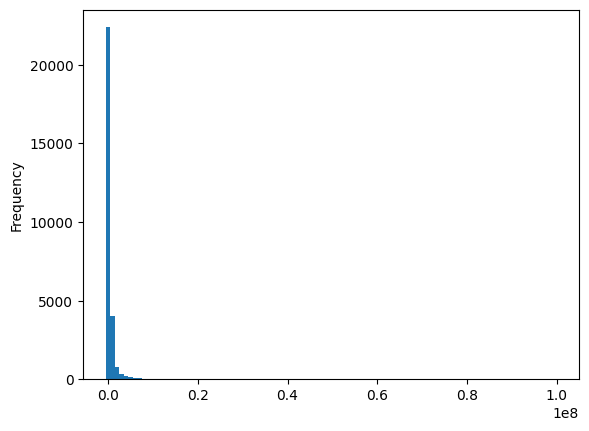

In [499]:
df_gifts['Foreign Gift Amount'].plot.hist(bins=100)

<Axes: ylabel='Frequency'>

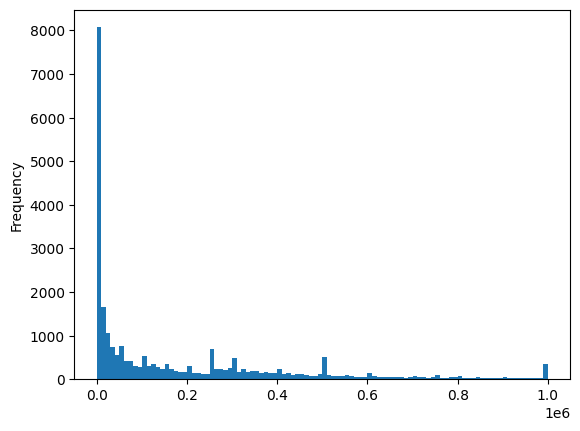

In [500]:
df_gifts['Foreign Gift Amount'].plot.hist(range=(0,1e+6), bins=100)

<Axes: ylabel='Frequency'>

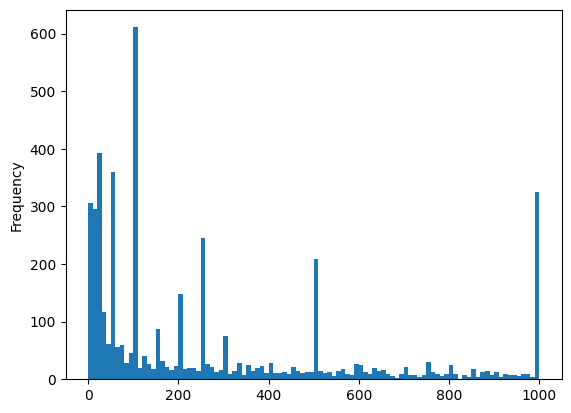

In [501]:
df_gifts['Foreign Gift Amount'].plot.hist(range=(0,1e+3), bins=100)

Explanation: The majority of foreign gifts tend to be relatively inexpensive with a lot of them being under $400. Nearly all of the gifts fall between 0 and a million dollars with a few outliers being more expensive than that.

Question 4.3

In [502]:
df_gifts.groupby(['Gift Type']).count()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Country of Giftor,Giftor Name
Gift Type,,,,,,,,,
Contract,17274,17274,17274,17274,17274,17274,17274,17274,15986
Monetary Gift,10936,10936,10936,10936,10936,10936,10936,10936,8473
Real Estate,11,11,11,11,11,11,11,11,11


In [503]:
df_gifts.shape

(28221, 10)

In [504]:
prop_contract = 17274/28221
prop_monetary_gift = 10936/28221
prop_real_estate = 11/28221

print("The proportion of gifts that are contracts is", prop_contract)
print("The proportion of gifts that are monetary gifts is", prop_monetary_gift)
print("The proportion of gifts that are real estate is", prop_real_estate)

The proportion of gifts that are contracts is 0.6120973742957372
The proportion of gifts that are monetary gifts is 0.3875128450444704
The proportion of gifts that are real estate is 0.00038978065979235324


Question 4.4

In [505]:
df_gifts.groupby(['Country of Giftor']).count().sort_values(by='ID', ascending=False).head(15)

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Giftor Name
Country of Giftor,,,,,,,,,
ENGLAND,3655,3655,3655,3655,3655,3655,3655,3655,3337
CHINA,2461,2461,2461,2461,2461,2461,2461,2461,2094
CANADA,2344,2344,2344,2344,2344,2344,2344,2344,2101
JAPAN,1896,1896,1896,1896,1896,1896,1896,1896,1626
SWITZERLAND,1676,1676,1676,1676,1676,1676,1676,1676,1530
SAUDI ARABIA,1610,1610,1610,1610,1610,1610,1610,1610,1514
FRANCE,1437,1437,1437,1437,1437,1437,1437,1437,1295
GERMANY,1394,1394,1394,1394,1394,1394,1394,1394,1295
HONG KONG,1080,1080,1080,1080,1080,1080,1080,1080,806


The table above shows the top 15 countries in terms of the number of gifts given.

In [506]:
(df_gifts.groupby(['Country of Giftor'])
 .sum(['Foreign Gift Amount'])
 .sort_values(by='Foreign Gift Amount', ascending=False)
 .head(15)

)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Country of Giftor,,,,
QATAR,14133760,207860000,29707239,2706240869
ENGLAND,47713393,861644700,156432837,1464906771
CHINA,33468243,601615400,105733871,1237952112
SAUDI ARABIA,20193035,355691800,69276531,1065205930
BERMUDA,2126107,31117600,5021524,899593972
CANADA,28437385,499182200,100285503,898160656
HONG KONG,14000547,244471700,46351589,887402529
JAPAN,22888812,475343200,81187641,655954776
SWITZERLAND,29044550,482048700,71959519,619899445


The table above shows the top 15 countries in terms of amount given.




Question 4.5

In [507]:
(df_gifts.groupby(['Institution Name'])
 .sum(['Foreign Gift Amount'])
 .sort_values(by='Foreign Gift Amount', ascending=False)
 .head(15)

)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Institution Name,,,,
Carnegie Mellon University,4131857,58031800,7644648,1477922504
Cornell University,12905892,177028300,28053214,1289937761
Harvard University,7137015,97621500,19288595,954803610
Massachusetts Institute of Technology,9477579,126759600,25079475,859071692
Yale University,5857775,78430000,23577424,613441311
Texas A&M University,9532916,136563200,16170594,521455050
Johns Hopkins University,12880872,186722300,38263148,502409595
Northwestern University,2994932,43648900,10759997,402316221
Georgetown University,1083975,14016500,4151008,379950511


The table above shows the top 15 institutions in terms of amount recevived.

<Axes: ylabel='Frequency'>

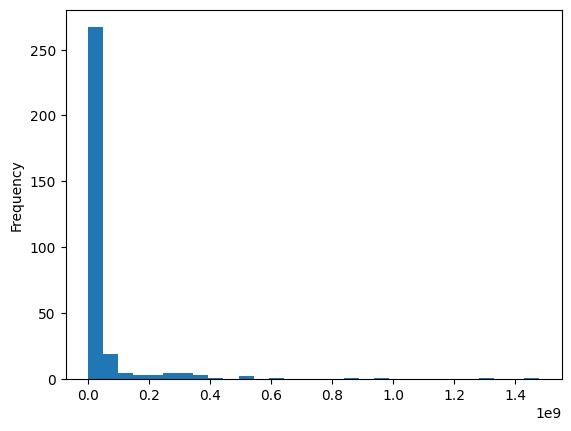

In [508]:
institution_totals = (df_gifts
    .groupby('Institution Name')['Foreign Gift Amount']
    .sum()
)

institution_totals.plot.hist(bins=30)

The histogram above shows the total amount received by all institutions

Question 4.6

In [509]:
(df_gifts.groupby(['Giftor Name'])
 .sum(['Foreign Gift Amount'])
 .sort_values(by='Foreign Gift Amount', ascending=False)
 .head(15)

)

,ID,OPEID,Foreign Gift Received Date,Foreign Gift Amount
Giftor Name,,,,
Qatar Foundation,6230548,89110300,11199907,1166503744
Qatar Foundation/Qatar National Res,196298,2711000,425002,796197000
Qatar Foundation for Education,138404,1942000,257508,373945215
Anonymous,5698993,79905200,11294891,338793629
Saudi Arabian Cultural Mission,7422014,136674400,20713305,275221475
HCL,139675,10566700,208835,190000000
Church of Jesus Christ of LDS,124928,1743400,301225,185203715
Emirates Institute for Advanced Sc,245229,3288000,1032913,170641244
QIC,33297,439800,87622,148355497


The table above shows the top 15 giftors who provide the most money in total.

# Question 5

Question 5.1

In [510]:
df_college_completion = pd.read_csv('./data/college_completion.csv')
df_college_completion.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


Question 5.2

In [511]:
df_college_completion.shape

(3798, 63)

There are 3798 observations and 63 variables in this data set.

Question 5.3

In [512]:
df_college_completion.columns

Index(['index', 'unitid', 'chronname', 'city', 'state', 'level', 'control',
       'basic', 'hbcu', 'flagship', 'long_x', 'lat_y', 'site', 'student_count',
       'awards_per_value', 'awards_per_state_value', 'awards_per_natl_value',
       'exp_award_value', 'exp_award_state_value', 'exp_award_natl_value',
       'exp_award_percentile', 'ft_pct', 'fte_value', 'fte_percentile',
       'med_sat_value', 'med_sat_percentile', 'aid_value', 'aid_percentile',
       'endow_value', 'endow_percentile', 'grad_100_value',
       'grad_100_percentile', 'grad_150_value', 'grad_150_percentile',
       'pell_value', 'pell_percentile', 'retain_value', 'retain_percentile',
       'ft_fac_value', 'ft_fac_percentile', 'vsa_year',
       'vsa_grad_after4_first', 'vsa_grad_elsewhere_after4_first',
       'vsa_enroll_after4_first', 'vsa_enroll_elsewhere_after4_first',
       'vsa_grad_after6_first', 'vsa_grad_elsewhere_after6_first',
       'vsa_enroll_after6_first', 'vsa_enroll_elsewhere_after6_first',
  

In [513]:
drop_cols2 = ['unitid', 'city', 'state',
       'basic', 'hbcu', 'flagship', 'long_x', 'lat_y', 'site', 'student_count',
       'awards_per_value', 'awards_per_state_value', 'awards_per_natl_value',
       'exp_award_value', 'exp_award_state_value', 'exp_award_natl_value',
       'exp_award_percentile', 'ft_pct', 'fte_value', 'fte_percentile',
       'med_sat_value', 'med_sat_percentile', 'aid_percentile',
       'endow_value', 'endow_percentile',
       'grad_100_percentile', 'grad_150_value', 'grad_150_percentile',
       'pell_value', 'pell_percentile', 'retain_value', 'retain_percentile',
       'ft_fac_value', 'ft_fac_percentile', 'vsa_year',
       'vsa_grad_after4_first', 'vsa_grad_elsewhere_after4_first',
       'vsa_enroll_after4_first', 'vsa_enroll_elsewhere_after4_first',
       'vsa_grad_after6_first', 'vsa_grad_elsewhere_after6_first',
       'vsa_enroll_after6_first', 'vsa_enroll_elsewhere_after6_first',
       'vsa_grad_after4_transfer', 'vsa_grad_elsewhere_after4_transfer',
       'vsa_enroll_after4_transfer', 'vsa_enroll_elsewhere_after4_transfer',
       'vsa_grad_after6_transfer', 'vsa_grad_elsewhere_after6_transfer',
       'vsa_enroll_after6_transfer', 'vsa_enroll_elsewhere_after6_transfer',
       'similar', 'state_sector_ct', 'carnegie_ct', 'counted_pct', 'nicknames',
       'cohort_size']

df_college_completion = df_college_completion.drop(columns = drop_cols2)
df_college_completion.head()

,index,chronname,level,control,aid_value,grad_100_value
0,0,Alabama A&M University,4-year,Public,7142.0,10.0
1,1,University of Alabama at Birmingham,4-year,Public,6088.0,29.4
2,2,Amridge University,4-year,Private not-for-profit,2540.0,0.0
3,3,University of Alabama at Huntsville,4-year,Public,6647.0,16.5
4,4,Alabama State University,4-year,Public,7256.0,8.8


In [514]:
pd.crosstab(df_college_completion['control'], df_college_completion['level'], dropna=False)

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


Most people in this data set completed a 4-year, private not-for-profit schooling while the least amount of people completed a 2-year, private not-for-profit schooling. For private schooling, most people opted for a 4-year experience while publc schooling had more people opt for a 2-year experience. In total, most people attended public schooling compared to private not-for-profit and private for-profit.

Question 5.4

<Axes: ylabel='Density'>

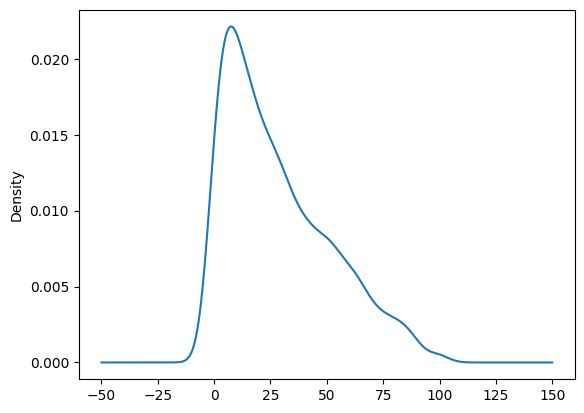

In [515]:
df_college_completion['grad_100_value'].plot.kde()

In [516]:
df_college_completion['grad_100_value'].describe()

,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


<Axes: xlabel='grad_100_value', ylabel='Density'>

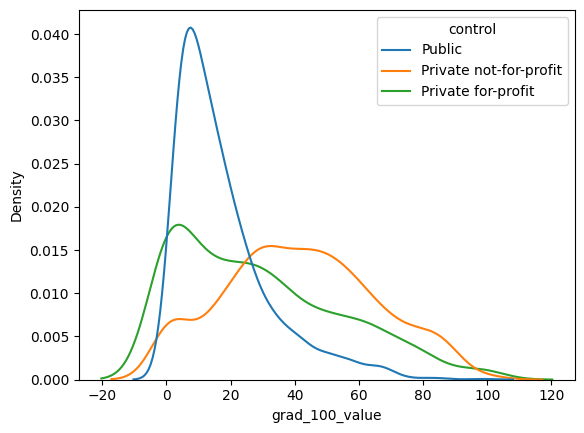

In [517]:
sns.kdeplot(df_college_completion, x='grad_100_value', hue = 'control', common_norm=False)

In [518]:
df_college_completion.groupby('control')['grad_100_value'].describe()

,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


Private not-for-profit schools seem to have the highest graduation rates at 41.66%.

Question 5.5

<Axes: xlabel='grad_100_value', ylabel='aid_value'>

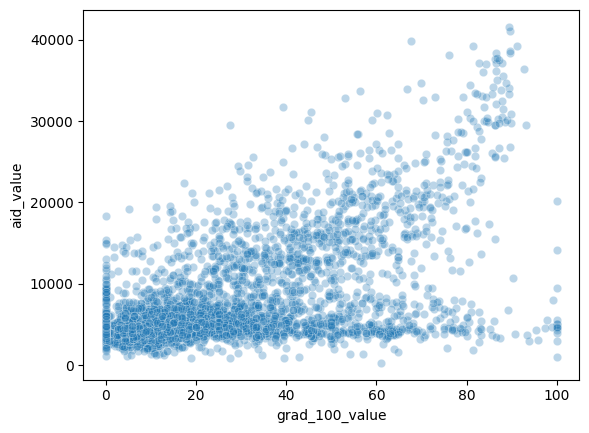

In [519]:
sns.scatterplot(x=df_college_completion['grad_100_value'], y = df_college_completion['aid_value'], alpha=.3)

In [520]:
var_list = ['grad_100_value', 'aid_value']
x = df_college_completion.loc[:, var_list]
x.describe()

,grad_100_value,aid_value
count,3467.000000,3797.000000
mean,28.364465,7960.445878
std,23.312730,6419.658196
min,0.000000,294.000000
25%,9.000000,4018.000000
50%,22.500000,5207.000000
75%,43.650000,9343.000000
max,100.000000,41580.000000


In [521]:
def minmax(x):
    u = (x-min(x))/(max(x)-min(x))
    return u

u=x.apply(minmax)
u.describe()

,grad_100_value,aid_value
count,3467.000000,3797.000000
mean,0.283645,0.185691
std,0.233127,0.155492
min,0.000000,0.000000
25%,0.090000,0.090200
50%,0.225000,0.118999
75%,0.436500,0.219178
max,1.000000,1.000000


In [522]:
u.cov()

,grad_100_value,aid_value
grad_100_value,0.054348,0.021463
aid_value,0.021463,0.024178


In [523]:
u.corr()

,grad_100_value,aid_value
grad_100_value,1.000000,0.575879
aid_value,0.575879,1.000000


The covariance suggests there is no clear linear relationship as teh values are very close to 0. The correlation shows that graduation rates are somewhat positivelt associated with aid values as the correlation value is 0.58.

<Axes: xlabel='grad_100_value', ylabel='aid_value'>

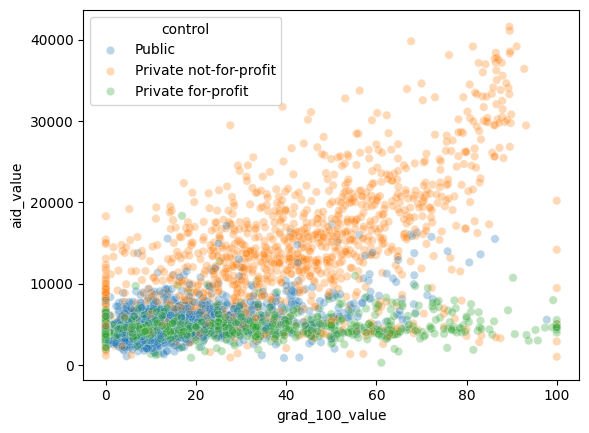

In [524]:
sns.scatterplot(data=df_college_completion, x='grad_100_value', y='aid_value', hue='control', alpha = 0.3)

Aid does not seem to change with graduation rates for Private for-profit and public schools; it is fairly constant. Aid does seem to vary positively with graduation rates for private not-for-profit schools.

# Question 7

Question 7.1

In [538]:
df_ames_prices = pd.read_csv('./data/ames_prices.csv')
df_ames_prices.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


In [539]:
df_ames_prices.columns

Index(['Order', 'PID', 'area', 'price', 'MS.SubClass', 'MS.Zoning',
       'Lot.Frontage', 'Lot.Area', 'Street', 'Alley', 'Lot.Shape',
       'Land.Contour', 'Utilities', 'Lot.Config', 'Land.Slope', 'Neighborhood',
       'Condition.1', 'Condition.2', 'Bldg.Type', 'House.Style',
       'Overall.Qual', 'Overall.Cond', 'Year.Built', 'Year.Remod.Add',
       'Roof.Style', 'Roof.Matl', 'Exterior.1st', 'Exterior.2nd',
       'Mas.Vnr.Type', 'Mas.Vnr.Area', 'Exter.Qual', 'Exter.Cond',
       'Foundation', 'Bsmt.Qual', 'Bsmt.Cond', 'Bsmt.Exposure',
       'BsmtFin.Type.1', 'BsmtFin.SF.1', 'BsmtFin.Type.2', 'BsmtFin.SF.2',
       'Bsmt.Unf.SF', 'Total.Bsmt.SF', 'Heating', 'Heating.QC', 'Central.Air',
       'Electrical', 'X1st.Flr.SF', 'X2nd.Flr.SF', 'Low.Qual.Fin.SF',
       'Bsmt.Full.Bath', 'Bsmt.Half.Bath', 'Full.Bath', 'Half.Bath',
       'Bedroom.AbvGr', 'Kitchen.AbvGr', 'Kitchen.Qual', 'TotRms.AbvGrd',
       'Functional', 'Fireplaces', 'Fireplace.Qu', 'Garage.Type',
       'Garage.Yr.B

In [540]:
drop_cols3 = ['area', 'MS.SubClass', 'MS.Zoning',
       'Lot.Frontage', 'Lot.Area', 'Street', 'Alley', 'Lot.Shape',
       'Land.Contour', 'Utilities', 'Lot.Config', 'Land.Slope', 'Neighborhood',
       'Condition.1', 'Condition.2', 'House.Style',
       'Overall.Qual', 'Overall.Cond', 'Year.Built', 'Year.Remod.Add',
       'Roof.Style', 'Roof.Matl', 'Exterior.1st', 'Exterior.2nd',
       'Mas.Vnr.Type', 'Mas.Vnr.Area', 'Exter.Qual', 'Exter.Cond',
       'Foundation', 'Bsmt.Qual', 'Bsmt.Cond', 'Bsmt.Exposure',
       'BsmtFin.Type.1', 'BsmtFin.SF.1', 'BsmtFin.Type.2', 'BsmtFin.SF.2',
       'Bsmt.Unf.SF', 'Total.Bsmt.SF', 'Heating', 'Heating.QC', 'Central.Air',
       'Electrical', 'X1st.Flr.SF', 'X2nd.Flr.SF', 'Low.Qual.Fin.SF',
       'Bsmt.Full.Bath', 'Bsmt.Half.Bath', 'Full.Bath', 'Half.Bath',
       'Bedroom.AbvGr', 'Kitchen.AbvGr', 'Kitchen.Qual', 'TotRms.AbvGrd',
       'Functional', 'Fireplaces', 'Fireplace.Qu', 'Garage.Type',
       'Garage.Yr.Blt', 'Garage.Finish', 'Garage.Cars', 'Garage.Area',
       'Garage.Qual', 'Garage.Cond', 'Paved.Drive', 'Wood.Deck.SF',
       'Open.Porch.SF', 'Enclosed.Porch', 'X3Ssn.Porch', 'Screen.Porch',
       'Pool.Area', 'Pool.QC', 'Fence', 'Misc.Feature', 'Misc.Val', 'Mo.Sold',
       'Yr.Sold', 'Sale.Type', 'Sale.Condition']

df_ames_prices = df_ames_prices.drop(columns = drop_cols3)
df_ames_prices.head()

,Order,PID,price,Bldg.Type
0,1,526301100,215000,1Fam
1,2,526350040,105000,1Fam
2,3,526351010,172000,1Fam
3,4,526353030,244000,1Fam
4,5,527105010,189900,1Fam


Question 7.2

<Axes: ylabel='Density'>

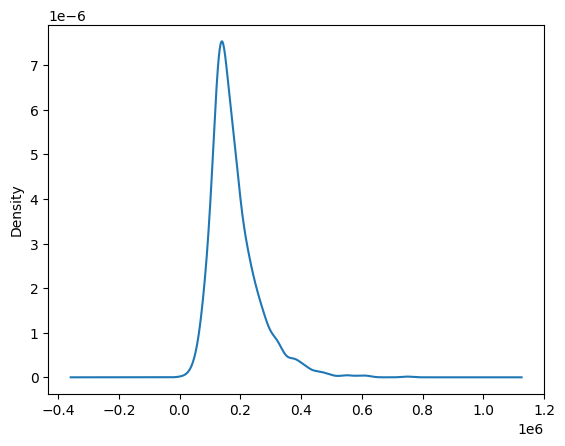

In [541]:
df_ames_prices['price'].plot.kde()

In [542]:
df_ames_prices['price'].describe()

,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


<Axes: xlabel='price', ylabel='Density'>

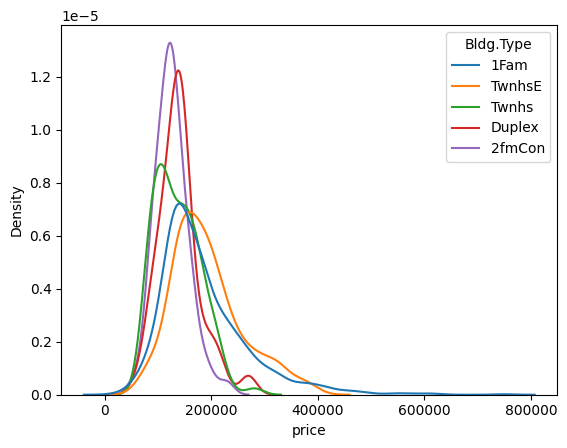

In [543]:
sns.kdeplot(df_ames_prices, x='price', hue = 'Bldg.Type', common_norm=False)

In [544]:
df_ames_prices.groupby('Bldg.Type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


On average, Town House End Units are the most expensive. 1 Family houses have the highest variance in transaction prices.

Question 7.3

<Axes: xlabel='price', ylabel='Proportion'>

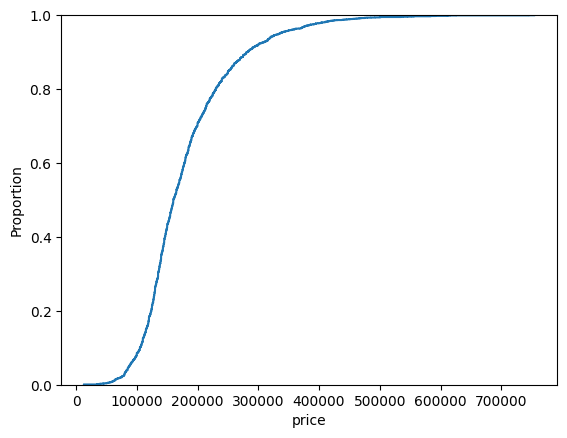

In [545]:
sns.ecdfplot(df_ames_prices['price'])

In [546]:
quant = 0
while quant <= 1:
  print(quant, "-quantile: ", np.quantile(df_ames_prices['price'],quant))
  quant = quant + 0.25

0 -quantile:  12789
0.25 -quantile:  129500.0
0.5 -quantile:  160000.0
0.75 -quantile:  213500.0
1.0 -quantile:  755000.0


Question 7.4

<Axes: xlabel='price'>

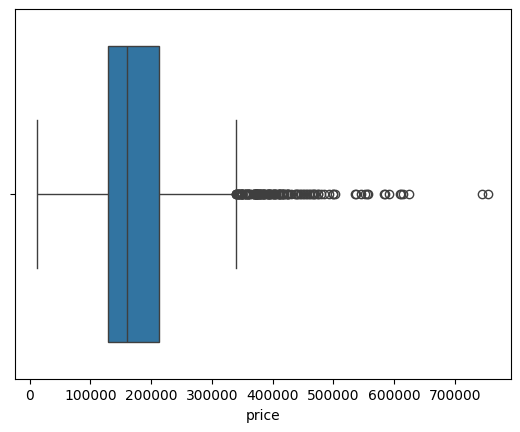

In [547]:
sns.boxplot(x=df_ames_prices['price'])

Yes, there are many outliers, all of them above the maximum.

<Axes: xlabel='price', ylabel='Bldg.Type'>

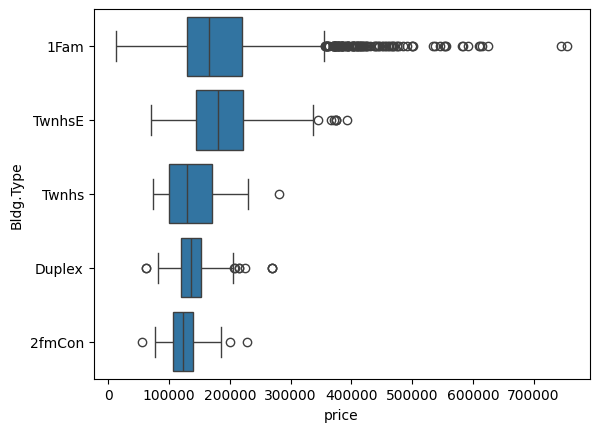

In [548]:
sns.boxplot(x=df_ames_prices['price'], y=df_ames_prices['Bldg.Type'])

1 Family houses have the highest range of prices while 2 Family Condos have the smallest range of prices. 1 Family houses are also the main supplier of outlier prices. The median price for Town House End Points is the largest while the median price for 2 Family Condos is the smallest.

Question 7.5

In [549]:
q1 = np.quantile(df_ames_prices['price'], 0.25)
q3 = np.quantile(df_ames_prices['price'], 0.75)
iqr = q3-q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr

In [551]:
df_ames_prices['outlier'] = ((df_ames_prices['price'] < lower_bound) | df_ames_prices['price'] > upper_bound).astype(int)
df_ames_prices['outlier'].value_counts()

,count
outlier,
0,2930


Question 7.6

In [552]:
df_ames_prices['Winsorized Price'] = ((df_ames_prices['price'] < lower_bound) * lower_bound
                                      + (df_ames_prices['price'] > upper_bound) * upper_bound
                                      + ((df_ames_prices['price'] >= lower_bound) & (df_ames_prices['price'] <= upper_bound))
                                      * df_ames_prices['price'])

df_ames_prices[['price', 'Winsorized Price']].describe()

,price,Winsorized Price
count,2930.000000,2930.000000
mean,180796.060068,177082.283959
std,79886.692357,67906.837135
min,12789.000000,12789.000000
25%,129500.000000,129500.000000
50%,160000.000000,160000.000000
75%,213500.000000,213500.000000
max,755000.000000,339500.000000


<Axes: ylabel='Density'>

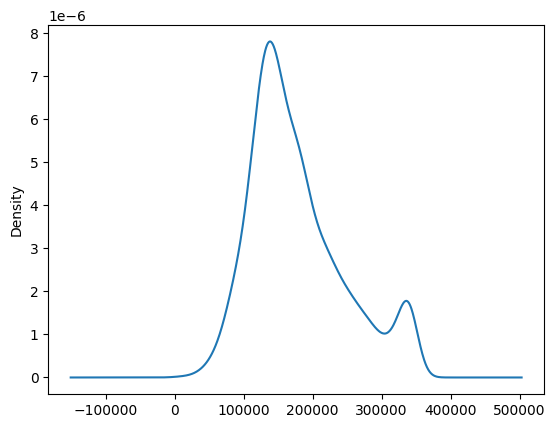

In [553]:
df_ames_prices['Winsorized Price'].plot.kde()

The mean has gone down since the outliers have essentially been removed, and the standard deviation has also decreased since the data is now closer together and has less variance from point to point.